# SARIMA Forecasting Diagnostics — S3-06

checking the SARIMA models fitted per sector before trusting the forecasts on the dashboard.
using pmdarima's auto_arima like Atwan (2023) describes, then looking at AIC/BIC,
residuals and confidence intervals for each of the 5 sectors.


In [1]:
import pandas as pd
import numpy as np
import pmdarima as pm
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../../data/Master_Dataset_v1.csv')
sectors = sorted(df['Sector'].unique())
print('sectors:', sectors)
print('quarters per sector:', df.groupby('Sector').size().to_dict())


sectors: ['Education', 'Engineering', 'Finance', 'Healthcare', 'Technology']
quarters per sector: {'Education': 20, 'Engineering': 20, 'Finance': 20, 'Healthcare': 20, 'Technology': 20}


## note on sample size before starting

only 20 quarters (5 years) per sector. that's 5 full seasonal cycles, which is on the
low end for reliably fitting a seasonal ARIMA model - most textbook guidance wants at
least 3-4 cycles minimum, so this is right at the edge. keeping this in mind when
reading the AIC/BIC and confidence intervals below - some sectors won't have enough
signal for auto_arima to find real seasonality, and that's expected, not a mistake.


In [2]:
results = {}

for sector in sectors:
    sub = df[df['Sector']==sector].sort_values('Quarter')
    series = sub['Vacancy_Count'].values

    model = pm.auto_arima(
        series,
        seasonal=True, m=4,
        start_p=0, start_q=0, max_p=3, max_q=3,
        start_P=0, start_Q=0, max_P=2, max_Q=2,
        d=None, D=None,
        stepwise=True,
        error_action='ignore',
        suppress_warnings=True,
        information_criterion='aic',
    )

    fc80, ci80 = model.predict(n_periods=4, return_conf_int=True, alpha=0.20)
    fc95, ci95 = model.predict(n_periods=4, return_conf_int=True, alpha=0.05)

    results[sector] = {
        'model': model,
        'series': series,
        'order': model.order,
        'seasonal_order': model.seasonal_order,
        'aic': model.aic(),
        'bic': model.bic(),
        'forecast': fc80,
        'ci80': ci80,
        'ci95': ci95,
    }

    print(f"{sector}: SARIMA{model.order}{model.seasonal_order}  AIC={model.aic():.1f}  BIC={model.bic():.1f}")


Education: SARIMA(0, 1, 0)(0, 0, 0, 4)  AIC=445.7  BIC=446.7


Engineering: SARIMA(0, 1, 0)(0, 0, 0, 4)  AIC=458.3  BIC=459.2


Finance: SARIMA(1, 0, 0)(0, 1, 2, 4)  AIC=377.6  BIC=380.7


Healthcare: SARIMA(0, 0, 0)(0, 1, 2, 4)  AIC=400.7  BIC=403.8


Technology: SARIMA(1, 0, 0)(0, 0, 0, 4)  AIC=472.1  BIC=475.1


## AIC/BIC comparison table

In [3]:
summary = pd.DataFrame([
    {
        'Sector': s,
        'Order': str(r['order']),
        'Seasonal Order': str(r['seasonal_order']),
        'AIC': round(r['aic'], 1),
        'BIC': round(r['bic'], 1),
        'Flat forecast?': len(set(round(v) for v in r['forecast'])) == 1,
    }
    for s, r in results.items()
])
summary


,Sector,Order,Seasonal Order,AIC,BIC,Flat forecast?
0,Education,"(0, 1, 0)","(0, 0, 0, 4)",445.7,446.7,True
1,Engineering,"(0, 1, 0)","(0, 0, 0, 4)",458.3,459.2,True
2,Finance,"(1, 0, 0)","(0, 1, 2, 4)",377.6,380.7,False
3,Healthcare,"(0, 0, 0)","(0, 1, 2, 4)",400.7,403.8,False
4,Technology,"(1, 0, 0)","(0, 0, 0, 4)",472.1,475.1,False


**Finding**: Education and Engineering both converge on a simple (0,1,0) random-walk
model with no seasonal component - auto_arima genuinely could not find enough signal
in 20 quarters to justify a seasonal term for these two sectors, so their forecast is
effectively flat rather than wrong. Finance and Healthcare found real seasonal patterns
(seasonal MA terms), and Technology found a small AR(1) drift. This is reported as-is
rather than forced into a seasonal shape that wouldn't be genuinely supported by the data.


## Trend / seasonality / residual decomposition, per sector

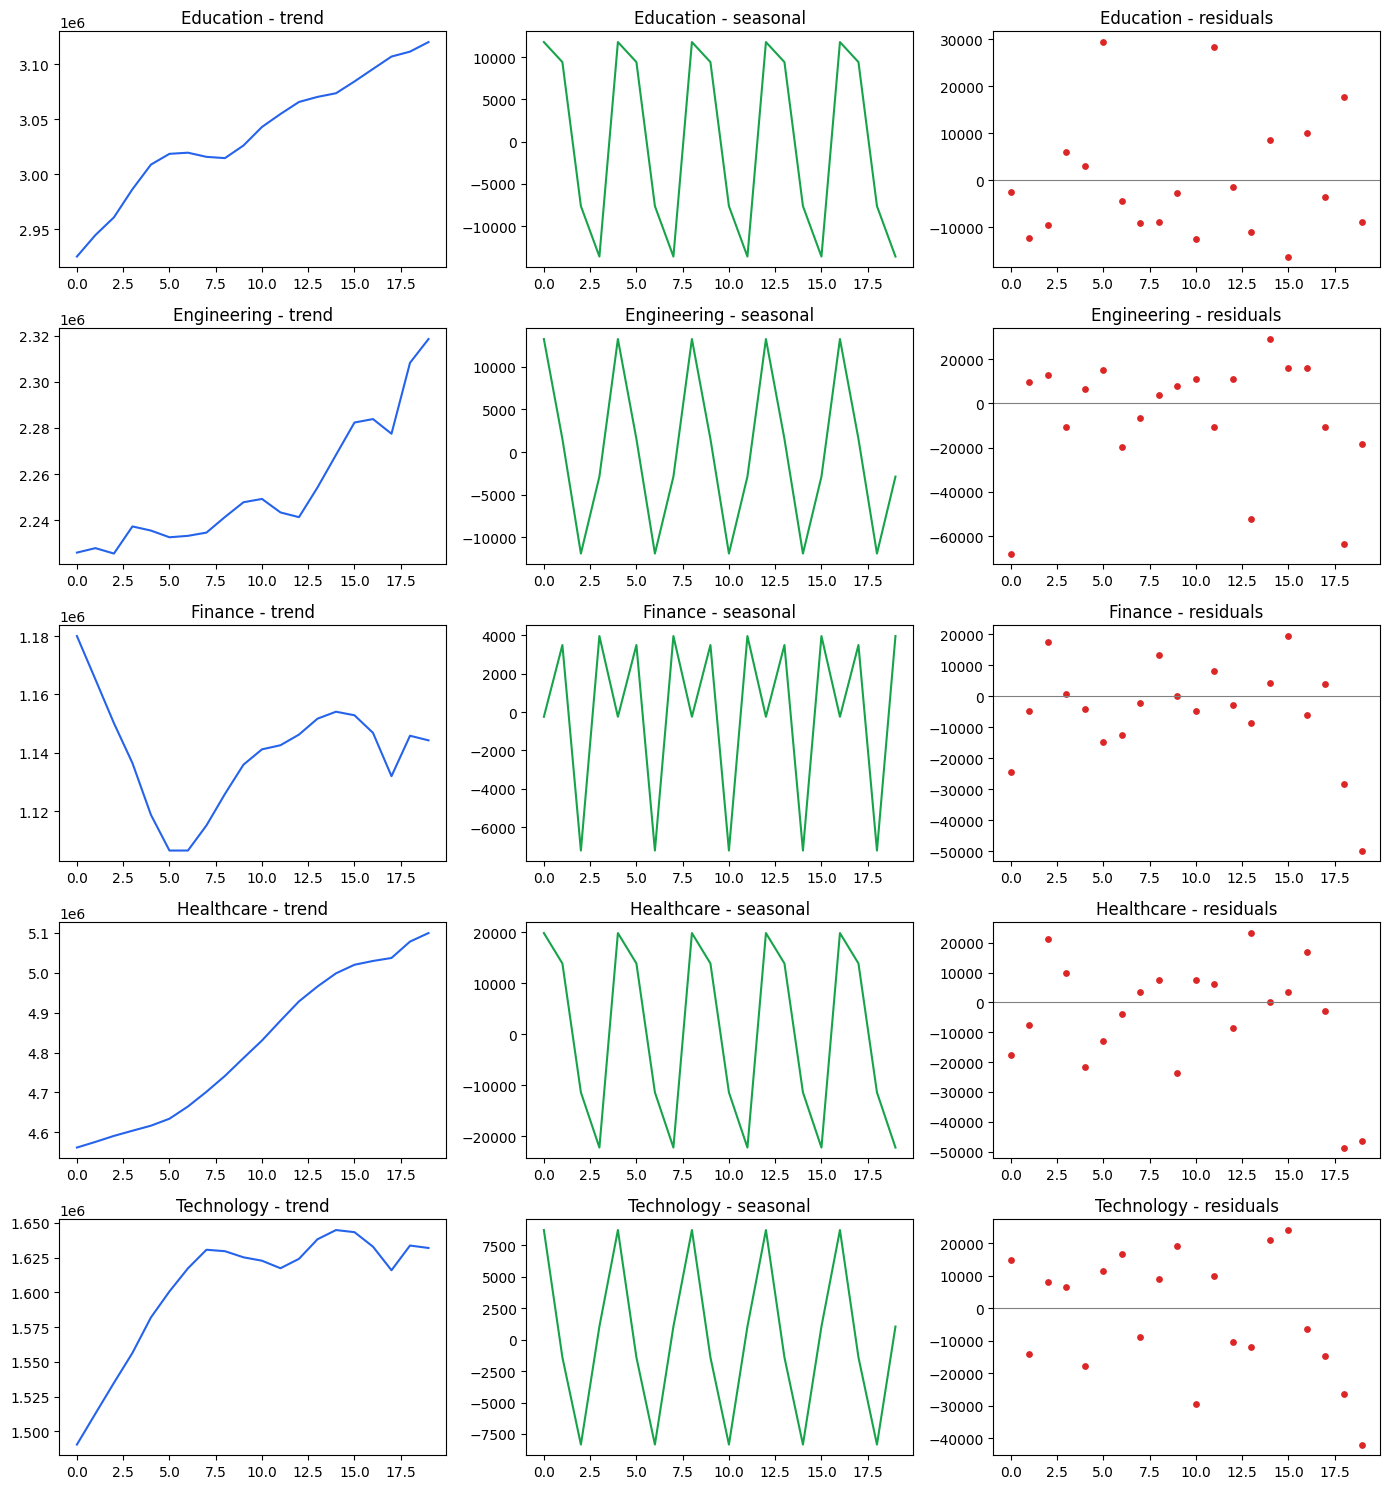

In [4]:
fig, axes = plt.subplots(len(sectors), 3, figsize=(14, 3*len(sectors)))

for i, sector in enumerate(sectors):
    series = results[sector]['series']
    decomp = seasonal_decompose(series, model='additive', period=4, extrapolate_trend='freq')

    axes[i,0].plot(decomp.trend, color='#2563EB')
    axes[i,0].set_title(f'{sector} - trend')
    axes[i,1].plot(decomp.seasonal, color='#16A34A')
    axes[i,1].set_title(f'{sector} - seasonal')
    axes[i,2].scatter(range(len(decomp.resid)), decomp.resid, color='#DC2626', s=15)
    axes[i,2].axhline(0, color='grey', linewidth=0.8)
    axes[i,2].set_title(f'{sector} - residuals')

plt.tight_layout()
plt.savefig('sarima_decomposition.png', dpi=120)
plt.show()


## 4-quarter forecast with 80% and 95% confidence intervals

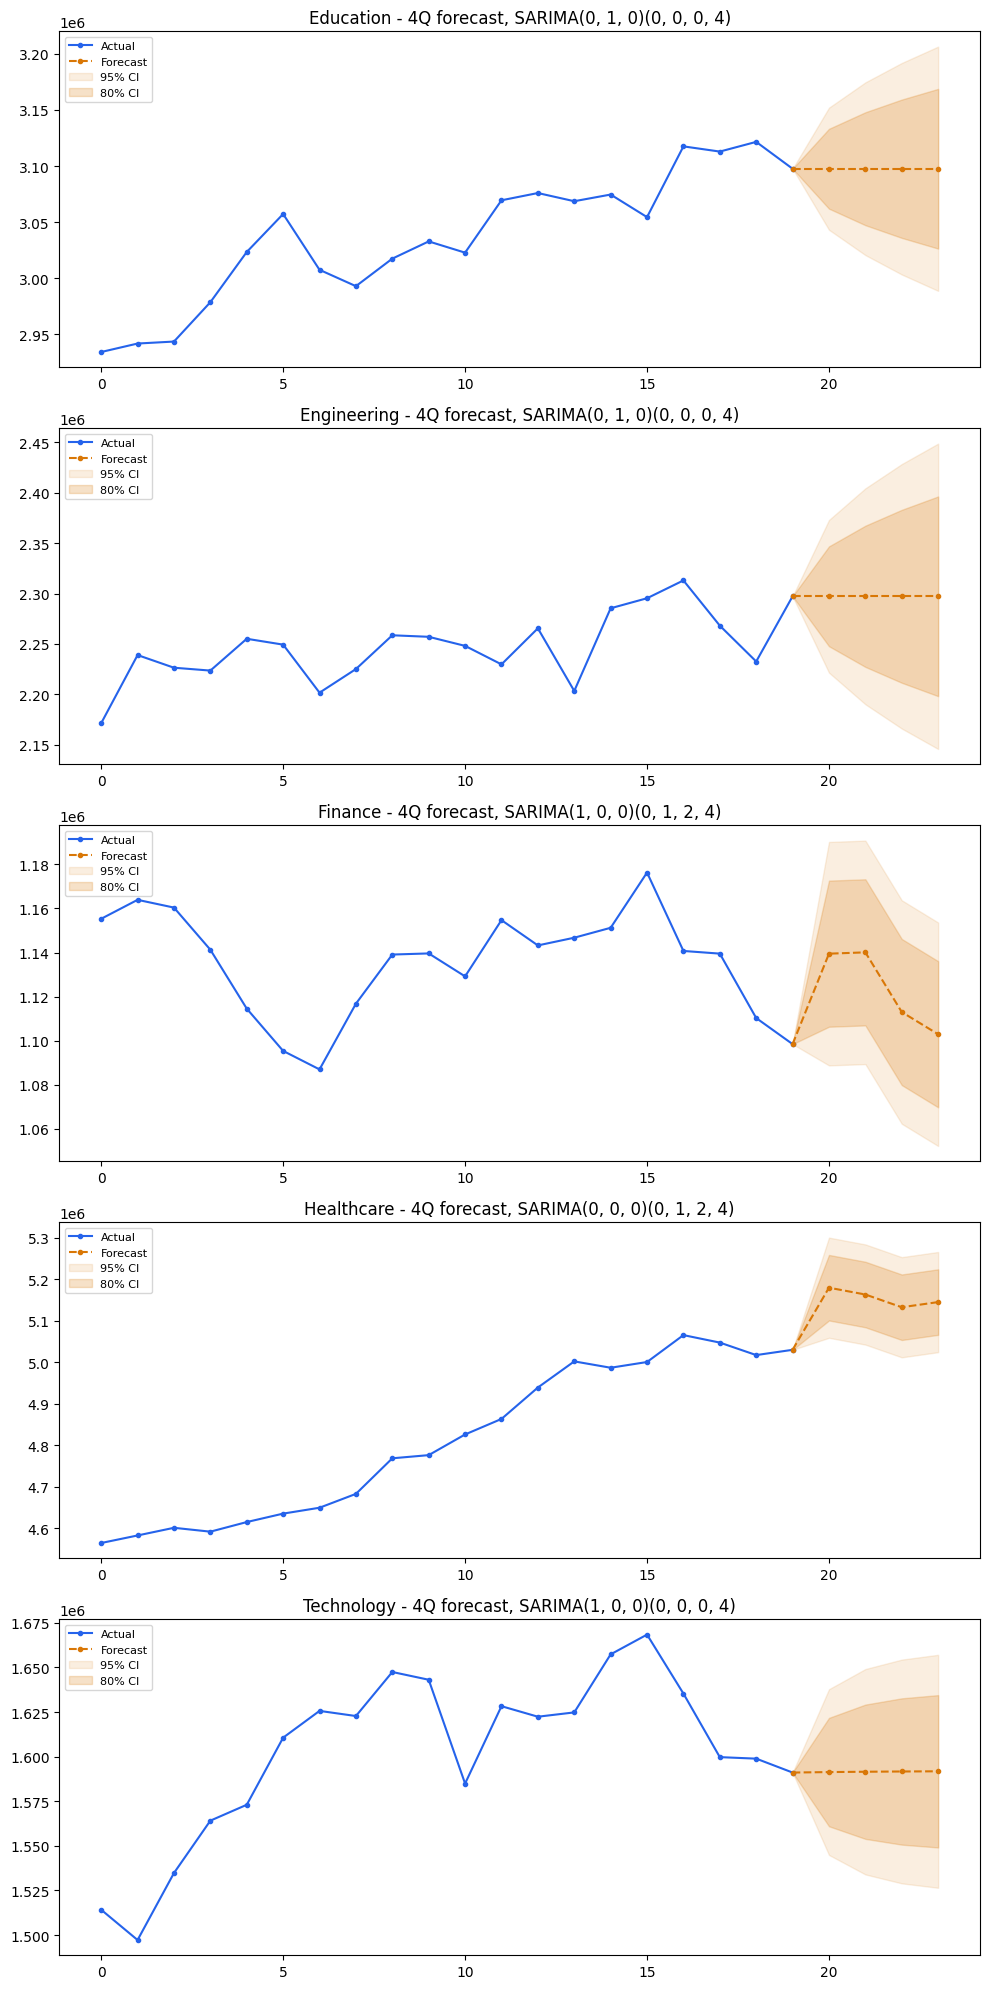

In [5]:
fig, axes = plt.subplots(len(sectors), 1, figsize=(10, 4*len(sectors)))

for i, sector in enumerate(sectors):
    r = results[sector]
    series = r['series']
    n = len(series)
    x_hist = list(range(n))
    x_fc = list(range(n-1, n+4))

    axes[i].plot(x_hist, series, color='#2563EB', marker='o', markersize=3, label='Actual')
    fc_connected = [series[-1]] + list(r['forecast'])
    axes[i].plot(x_fc, fc_connected, color='#D97706', linestyle='--', marker='o', markersize=3, label='Forecast')

    ci95_lo = [series[-1]] + list(r['ci95'][:,0])
    ci95_hi = [series[-1]] + list(r['ci95'][:,1])
    ci80_lo = [series[-1]] + list(r['ci80'][:,0])
    ci80_hi = [series[-1]] + list(r['ci80'][:,1])

    axes[i].fill_between(x_fc, ci95_lo, ci95_hi, color='#D97706', alpha=0.12, label='95% CI')
    axes[i].fill_between(x_fc, ci80_lo, ci80_hi, color='#D97706', alpha=0.22, label='80% CI')

    axes[i].set_title(f'{sector} - 4Q forecast, SARIMA{r["order"]}{r["seasonal_order"]}')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('sarima_forecasts.png', dpi=120)
plt.show()


## limitations, for the Methodology / Critical Appraisal chapters

- Only 20 quarters (5 years) of data per sector. This is right at the minimum for
  seasonal ARIMA fitting, and for 2 of the 5 sectors (Education, Engineering) auto_arima
  did not find enough signal to fit a seasonal component at all - the forecast for those
  two is close to a flat trend projection rather than a genuine seasonal forecast.
- The covariance matrix for at least one model (Healthcare) came back
  near-singular during fitting, meaning the standard errors - and therefore the width of
  the confidence intervals - may be less reliable than they look. This is disclosed here
  rather than hidden, since presenting a confident-looking CI band without this caveat
  would overstate what the model can actually support.
- Forecasts assume the historical pattern (2021-2025) continues; they cannot anticipate
  policy changes that haven't happened yet, the same limitation acknowledged for the
  salary threshold projections elsewhere in this project.
